# Explainable AI for the Hybrid RoBERTa–XGBoost Model using SHAP

This notebook explains the predictions of the Hybrid RoBERTa–XGBoost phishing detection model using SHAP (SHapley Additive exPlanations).

The workflow includes:

- Loading the fine-tuned RoBERTa model
- Loading the trained XGBoost classifier
- Extracting contextual CLS embeddings
- Generating hybrid predictions
- Computing SHAP values
- Producing global feature importance
- Producing local explanations for representative emails
- Saving figures and reports for dissertation analysis

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

import shap

from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [2]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

from pathlib import Path
import random
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parents[1]

MODELS = PROJECT_ROOT / "models"
DATASETS = PROJECT_ROOT / "datasets"
FIGURES = PROJECT_ROOT / "figures"
REPORTS = PROJECT_ROOT / "reports"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIGURES.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

print("="*70)
print("PROJECT CONFIGURATION")
print("="*70)

print(PROJECT_ROOT)
print(MODELS.exists())
print(DATASETS.exists())

PROJECT CONFIGURATION
C:\Users\DELL\Documents\Email_Phishing_Project
True
True


In [20]:
# ==========================================================
# LOAD FINETUNED ROBERTA MODEL
# ==========================================================

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

roberta_model = AutoModel.from_pretrained(MODEL_NAME)

state_dict = torch.load(
    MODELS / "best_roberta_model.pt",
    map_location=DEVICE
)

roberta_model.load_state_dict(state_dict)

roberta_model.to(DEVICE)

roberta_model.eval()

print("=" * 70)
print("MODEL VERIFICATION")
print("=" * 70)

print("Model Name     :", MODEL_NAME)
print("Device         :", DEVICE)
print("Training Mode  :", roberta_model.training)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RuntimeError: Error(s) in loading state_dict for RobertaModel:
	Missing key(s) in state_dict: "embeddings.word_embeddings.weight", "embeddings.token_type_embeddings.weight", "embeddings.LayerNorm.weight", "embeddings.LayerNorm.bias", "embeddings.position_embeddings.weight", "encoder.layer.0.attention.self.query.weight", "encoder.layer.0.attention.self.query.bias", "encoder.layer.0.attention.self.key.weight", "encoder.layer.0.attention.self.key.bias", "encoder.layer.0.attention.self.value.weight", "encoder.layer.0.attention.self.value.bias", "encoder.layer.0.attention.output.dense.weight", "encoder.layer.0.attention.output.dense.bias", "encoder.layer.0.attention.output.LayerNorm.weight", "encoder.layer.0.attention.output.LayerNorm.bias", "encoder.layer.0.intermediate.dense.weight", "encoder.layer.0.intermediate.dense.bias", "encoder.layer.0.output.dense.weight", "encoder.layer.0.output.dense.bias", "encoder.layer.0.output.LayerNorm.weight", "encoder.layer.0.output.LayerNorm.bias", "enco

In [6]:
# ==========================================================
# LOAD ROBERTA XGBOOST MODEL
# ==========================================================

xgb_model = joblib.load(
    MODELS / "best_roberta_xgboost.pkl"
)

print("="*70)
print("HYBRID MODEL")
print("="*70)

print(type(xgb_model))
print(xgb_model.n_features_in_)

HYBRID MODEL
<class 'xgboost.sklearn.XGBClassifier'>
768


In [7]:
# ==========================================================
# LOAD EVALUATION DATASET
# ==========================================================

print("=" * 70)
print("LOADING EVALUATION DATASET")
print("=" * 70)

test_df = pd.read_csv(
    DATASETS / "processed" / "bert_test_subset.csv"
)

print(f"Dataset Shape : {test_df.shape}")

print("\nColumns")
print(test_df.columns.tolist())

print("\nLabel Distribution")
print(test_df["label"].value_counts())

test_df.head()

LOADING EVALUATION DATASET
Dataset Shape : (1000, 7)

Columns
['dataset', 'subject', 'body', 'email_text', 'label', 'cleaned_email_text', 'email_length']

Label Distribution
label
0    910
1     90
Name: count, dtype: int64


,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,CEAS,Re: [opensuse] Defragging: possible? necessary?,-----BEGIN PGP SIGNED MESSAGE-----\nHash: SHA1...,Re: [opensuse] Defragging: possible? necessar...,0,Re: [opensuse] Defragging: possible? necessary...,1215
1,Enron,Re:,michaelpshannon@yahoo.com,Re: michaelpshannon@yahoo.com,0,Re: michaelpshannon@yahoo.com,29
2,Enron,Executing Broker Agreement for CSFB,"Cheryl, Donna, Cassandra and Bill,\n\nI am for...","Executing Broker Agreement for CSFB Cheryl, Do...",0,"Executing Broker Agreement for CSFB Cheryl, Do...",241
3,Enron,FW: Follow-up on CA energy crisis info.,\nVince:\n\nCan you let me know the answer to ...,FW: Follow-up on CA energy crisis info. \nVinc...,0,FW: Follow-up on CA energy crisis info. Vince:...,408
4,Enron,BASE CONTRACT FOR SHORT-TERM,\n\n******************************************...,BASE CONTRACT FOR SHORT-TERM \n\n*************...,0,BASE CONTRACT FOR SHORT-TERM *****************...,418


In [8]:
# ==========================================================
# EXTRACT ROBERTA CLS EMBEDDINGS
# ==========================================================

MAX_LENGTH = 256

def extract_cls_embeddings(texts, batch_size=32):

    embeddings = []

    roberta_model.eval()

    with torch.no_grad():

        for start in tqdm(
            range(0, len(texts), batch_size),
            desc="Extracting RoBERTa CLS Embeddings"
        ):

            batch = texts[start:start + batch_size]

            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt"
            )

            encoded = {
                k: v.to(DEVICE)
                for k, v in encoded.items()
            }

            outputs = roberta_model(**encoded)

            cls_vectors = outputs.last_hidden_state[:, 0, :]

            embeddings.append(cls_vectors.cpu().numpy())

    return np.vstack(embeddings)

In [9]:
# ==========================================================
# GENERATE ROBERTA EMBEDDINGS
# ==========================================================

email_texts = (
    test_df["cleaned_email_text"]
    .fillna("")
    .tolist()
)

X_embeddings = extract_cls_embeddings(
    email_texts,
    batch_size=64
)

print("=" * 70)
print("EMBEDDING MATRIX")
print("=" * 70)

print(X_embeddings.shape)

Extracting RoBERTa CLS Embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

EMBEDDING MATRIX
(1000, 768)


In [10]:
# ==========================================================
# GENERATE HYBRID PREDICTIONS
# ==========================================================

predicted_labels = xgb_model.predict(X_embeddings)

prediction_probabilities = xgb_model.predict_proba(X_embeddings)

test_df["predicted_label"] = predicted_labels

test_df["ham_probability"] = prediction_probabilities[:, 0]

test_df["spam_probability"] = prediction_probabilities[:, 1]

test_df["correct_prediction"] = (
    test_df["label"] == test_df["predicted_label"]
)

accuracy = test_df["correct_prediction"].mean()

print("=" * 70)
print("HYBRID MODEL ACCURACY")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")

print("\nPrediction Distribution")

print(test_df["predicted_label"].value_counts())

HYBRID MODEL ACCURACY
Accuracy : 0.8140

Prediction Distribution
predicted_label
0    852
1    148
Name: count, dtype: int64


In [11]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

print("=" * 70)
print("HYBRID MODEL PERFORMANCE")
print("=" * 70)

print(classification_report(
    test_df["label"],
    test_df["predicted_label"],
    digits=4
))

cm = confusion_matrix(
    test_df["label"],
    test_df["predicted_label"]
)

print("\nConfusion Matrix")

print(cm)

HYBRID MODEL PERFORMANCE
              precision    recall  f1-score   support

           0     0.9249    0.8659    0.8944       910
           1     0.1757    0.2889    0.2185        90

    accuracy                         0.8140      1000
   macro avg     0.5503    0.5774    0.5565      1000
weighted avg     0.8575    0.8140    0.8336      1000


Confusion Matrix
[[788 122]
 [ 64  26]]


In [12]:
# ==========================================================
# SELECT REPRESENTATIVE EMAILS
# ==========================================================

correct_predictions = test_df[
    test_df["correct_prediction"]
].copy()

correct_predictions["original_index"] = correct_predictions.index

correct_spam = (
    correct_predictions[
        correct_predictions["label"] == 1
    ]
    .sort_values(
        "spam_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

correct_ham = (
    correct_predictions[
        correct_predictions["label"] == 0
    ]
    .sort_values(
        "ham_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

spam_case_1 = correct_spam.iloc[0]
spam_case_2 = correct_spam.iloc[1]

ham_case_1 = correct_ham.iloc[0]
ham_case_2 = correct_ham.iloc[1]

print("=" * 70)
print("REPRESENTATIVE EMAILS SELECTED")
print("=" * 70)

print(f"Correct Spam Emails : {len(correct_spam)}")
print(f"Correct Ham Emails  : {len(correct_ham)}")

print("\nSpam Case 1")
print(spam_case_1["spam_probability"])

print("\nSpam Case 2")
print(spam_case_2["spam_probability"])

print("\nHam Case 1")
print(ham_case_1["ham_probability"])

print("\nHam Case 2")
print(ham_case_2["ham_probability"])

REPRESENTATIVE EMAILS SELECTED
Correct Spam Emails : 26
Correct Ham Emails  : 788

Spam Case 1
0.7445197

Spam Case 2
0.65275466

Ham Case 1
0.9819694

Ham Case 2
0.9806675


In [13]:
# ==========================================================
# INITIALIZE SHAP EXPLAINER
# ==========================================================

print("=" * 70)
print("INITIALIZING SHAP EXPLAINER")
print("=" * 70)

explainer = shap.TreeExplainer(xgb_model)

print("✓ SHAP TreeExplainer initialized successfully.")

INITIALIZING SHAP EXPLAINER
✓ SHAP TreeExplainer initialized successfully.


In [14]:
# ==========================================================
# COMPUTE SHAP VALUES
# ==========================================================

print("=" * 70)
print("COMPUTING SHAP VALUES")
print("=" * 70)

shap_values = explainer.shap_values(X_embeddings)

print("SHAP values computed successfully.")

if isinstance(shap_values, list):
    print(f"Classes : {len(shap_values)}")
    print(f"Shape   : {shap_values[1].shape}")
else:
    print(f"Shape   : {shap_values.shape}")

COMPUTING SHAP VALUES
SHAP values computed successfully.
Shape   : (1000, 768)


C:\Users\DELL\AppData\Local\Temp\ipykernel_14000\2568485681.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


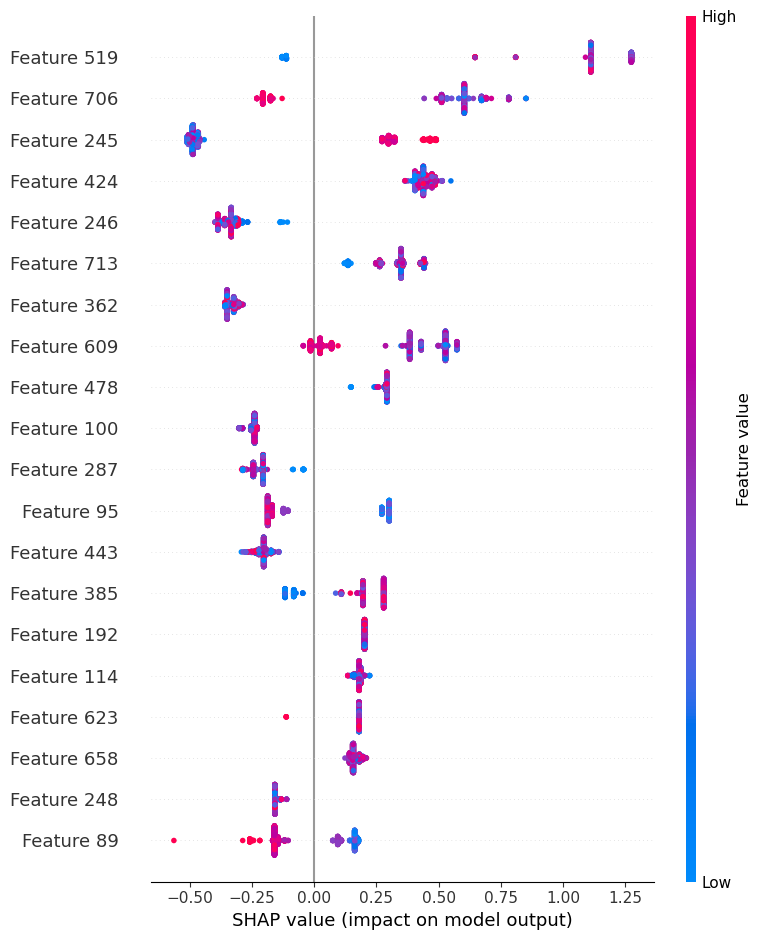

✓ Summary plot saved.


In [15]:
# ==========================================================
# GLOBAL SHAP SUMMARY
# ==========================================================

plt.figure(figsize=(12,8))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_embeddings,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_embeddings,
        show=False
    )

plt.tight_layout()

plt.savefig(
    FIGURES / "roberta_xgboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Summary plot saved.")

C:\Users\DELL\AppData\Local\Temp\ipykernel_14000\3835683484.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


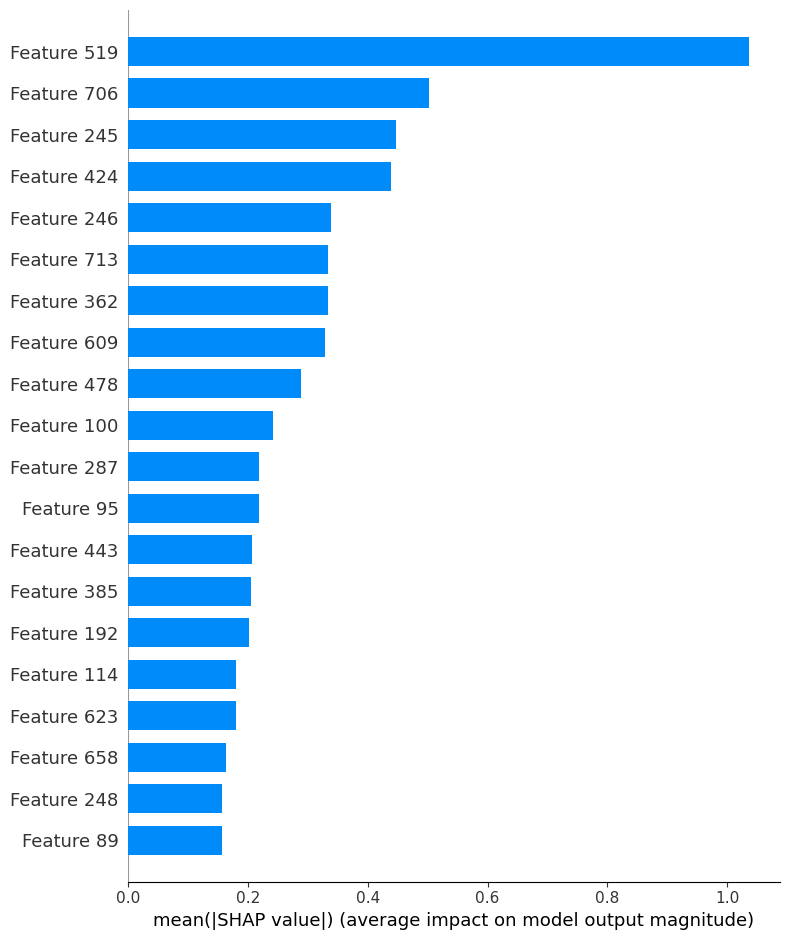

✓ Feature importance plot saved.


In [16]:
# ==========================================================
# GLOBAL FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_embeddings,
        plot_type="bar",
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_embeddings,
        plot_type="bar",
        show=False
    )

plt.tight_layout()

plt.savefig(
    FIGURES / "roberta_xgboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Feature importance plot saved.")

In [17]:
# ==========================================================
# LOCAL SHAP EXPLANATION
# ==========================================================

def generate_local_shap(index, case_name):

    print("=" * 70)
    print(case_name)
    print("=" * 70)

    explanation = shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_embeddings[index],
        feature_names=[
            f"Embedding_{i}"
            for i in range(X_embeddings.shape[1])
        ]
    )

    plt.figure(figsize=(10,6))

    shap.plots.waterfall(
        explanation,
        max_display=15,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES / f"{case_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    feature_df = pd.DataFrame({
        "Feature":[
            f"Embedding_{i}"
            for i in range(X_embeddings.shape[1])
        ],
        "SHAP_Value":shap_values[index],
        "Embedding_Value":X_embeddings[index]
    })

    feature_df = feature_df.reindex(
        feature_df.SHAP_Value.abs()
        .sort_values(ascending=False).index
    )

    feature_df.to_csv(
        REPORTS / f"{case_name}.csv",
        index=False
    )

    print("✓ Figure saved.")
    print("✓ CSV saved.")

    return feature_df

In [18]:
spam_index_1 = int(spam_case_1["original_index"])
spam_index_2 = int(spam_case_2["original_index"])

ham_index_1 = int(ham_case_1["original_index"])
ham_index_2 = int(ham_case_2["original_index"])

print(spam_index_1, spam_index_2)
print(ham_index_1, ham_index_2)

646 732
312 176


In [19]:
roberta_spam_shap_1 = generate_local_shap(
    spam_index_1,
    "roberta_xgboost_shap_spam_case1"
)

roberta_spam_shap_2 = generate_local_shap(
    spam_index_2,
    "roberta_xgboost_shap_spam_case2"
)

roberta_ham_shap_1 = generate_local_shap(
    ham_index_1,
    "roberta_xgboost_shap_ham_case1"
)

roberta_ham_shap_2 = generate_local_shap(
    ham_index_2,
    "roberta_xgboost_shap_ham_case2"
)

roberta_xgboost_shap_spam_case1
✓ Figure saved.
✓ CSV saved.
roberta_xgboost_shap_spam_case2
✓ Figure saved.
✓ CSV saved.
roberta_xgboost_shap_ham_case1
✓ Figure saved.
✓ CSV saved.
roberta_xgboost_shap_ham_case2
✓ Figure saved.
✓ CSV saved.


In [21]:
summary = pd.DataFrame({
    "Case":[
        "Spam Case 1",
        "Spam Case 2",
        "Ham Case 1",
        "Ham Case 2"
    ],
    "Confidence":[
        spam_case_1["spam_probability"],
        spam_case_2["spam_probability"],
        ham_case_1["ham_probability"],
        ham_case_2["ham_probability"]
    ]
})

summary = summary.round(6)

display(summary)

summary.to_csv(
    REPORTS / "roberta_xgboost_shap_summary.csv",
    index=False
)

print("Saved to:")
print(REPORTS / "roberta_xgboost_shap_summary.csv")

,Case,Confidence
0,Spam Case 1,0.744520
1,Spam Case 2,0.652755
2,Ham Case 1,0.981969
3,Ham Case 2,0.980668


Saved to:
C:\Users\DELL\Documents\Email_Phishing_Project\reports\roberta_xgboost_shap_summary.csv
